In [32]:

import jax.numpy as jnp

import sys

sys.path.append("./siegel_analyses/scripts/")
sys.path.insert(1,'./ibl_analyses/scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import psychofit as psy

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from pathlib import Path
import pickle

# Load the data
DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"
with open(DATA_DIR / "raw_behavior_all.pkl", "rb") as f:
    n_trials, cs_trials = pickle.load(f)
with open(DATA_DIR / "100_folds_1_time_point_all.pkl", "rb") as f:
    [params, train_data_folds, test_data_folds] = pickle.load(f)

In [ ]:
from utils import get_dists, get_kneigh_decreasing
# Relaxing also the number of folds and shuffles
n_folds = 50
n_shuffles = 250

all_c_corrs = []
all_zscores = []
all_preds_top = []

all_dist_neural = []
all_dist_cc = []

neurons_test=[]

for fold in tqdm.trange(n_folds):
    train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]
    try: 
        dist_neural,dist_cc,cs = get_dists(train_fold,test_fold,n_trials_total=n_trials,metric='area')
    except np.linalg.LinAlgError:
        print("linalg error")
        continue
    
    all_dist_neural.append(dist_neural)
    all_dist_cc.append(dist_cc)
    
    S = dist_neural.shape[0]
    flat_dist_neural = dist_neural[jnp.triu_indices(S,1)]
    flat_dist_cc = dist_cc[jnp.triu_indices(S,1)]

    r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
    W = 10
    preds_top = get_kneigh_decreasing(dist_neural,cs,S, W=W)
    
    all_preds_top.append(preds_top)

    # compute shuffled correlation
    corrs_shuffle = []
    flat_dist_cc_s =flat_dist_cc.copy()
    for _ in range(n_shuffles):
        perm = np.random.permutation(S)
        shuffled_dist_cc = dist_cc[perm, :][:, perm]
        flat_dist_cc_s = shuffled_dist_cc[jnp.triu_indices(S,1)]
        r_s,_ = sts.pearsonr(flat_dist_cc_s,flat_dist_neural)
        corrs_shuffle.append(r_s)

    # save z-scored correlation
    all_zscores.append((r - np.mean(corrs_shuffle))/np.std(corrs_shuffle))
    all_c_corrs.append([r,corrs_shuffle])

# convert to arrays for easier downstream handling
all_dist_neural = np.array(all_dist_neural, dtype=object)
all_dist_cc = np.array(all_dist_cc, dtype=object)
all_zscores = np.array(all_zscores)

all_preds_top = np.array(all_preds_top, dtype=object)
all_c_corrs = np.array(all_c_corrs, dtype=object)

# Taking the fold with the best correlation between neural and behavior

data_corrs = np.array(all_c_corrs)[:,0]
dist_neural = all_dist_neural[np.argmax(data_corrs)].copy()
dist_cc = all_dist_cc[np.argmax(data_corrs)].copy()

# for plotting
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0],0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0],0)] = np.nan


  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:12<09:57, 12.19s/it]

In [73]:
# No CV
DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"
with open(DATA_DIR / "raw_behavior_all.pkl", "rb") as f:
    n_trials, cs_trials = pickle.load(f)

with open(DATA_DIR / "nocv_1_time_point_all.pkl", "rb") as f:
    [params,train_data] = pickle.load(f)

# Compute neural and behavioral distances for the non-cross-validated data
dist_neural_nocv,dist_cc_nocv,cs = get_dists(train_data[0],n_trials_total=n_trials,metric='area')

S = dist_neural_nocv.shape[0]
# take upper triangle
flat_dist_neural = dist_neural_nocv[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc_nocv[jnp.triu_indices(S,1)]

r_dist,p_dist = sts.pearsonr(flat_dist_cc,flat_dist_neural)



In [ ]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)

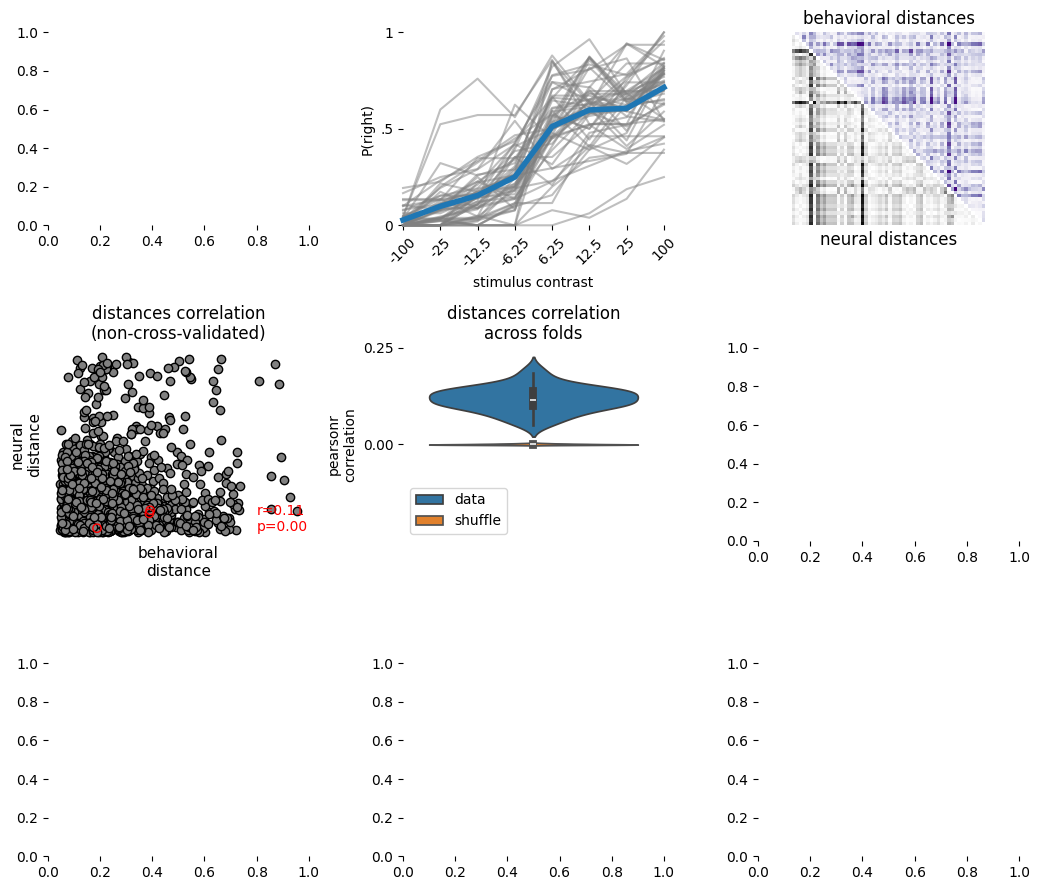

In [ ]:
# FIGURE 1-4
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,6*1.5))

# Adding to the figure 
examples_idx= [10,12,19]

axes = axes.flatten()

### First, the PSYCHOMETRIC CURVES
contrast = [-100.  ,  -25.  ,  -12.5 ,   -6.25,    0.  ,    6.25,   12.5 ,
         25.  ,  100.  ]

avg_cc = [np.mean(c==1,0) for c in cs_trials]

choices = convert_to_rw_choices(cs_trials)
axes[1].plot(choices.T, color='gray', alpha=0.5,clip_on=False)
axes[1].plot(np.nanmean(choices,0), lw=4,clip_on=False)   
axes[1].set_ylabel("P(right)")
axes[1].set_xlabel("stimulus contrast")
axes[1].set_xticks(range(len(contrast)-1),[-100,-25,-12.5,-6.25,6.25,12.5,25,100],rotation=45)
axes[1].set_yticks([0,0.5,1],[0,'.5',1])
axes[1].set_ylim(0,1)
axes[1].set_xlim(0,7)


colors = np.array(sns.color_palette(None, S))

### Second DISTANCE MATRICES
dist_neural = np.asarray(dist_neural, dtype=float)
dist_cc = np.asarray(dist_cc, dtype=float)
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0], 0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0], 0)] = np.nan

axes[2].imshow(dist_neural_,cmap="Grays")

axes[2].set_xlabel("neural distances", fontsize=12)

axes[2].set_title('behavioral distances', fontsize=12)
axes[2].imshow(dist_cc_,cmap="Purples")
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,left=False,labelleft=False,right=True,labelright=True)

#change ticks fontsize
for ti,tick in enumerate(axes[2].get_xticklabels()):
    tick.set_fontsize(8)
    axes[2].get_yticklabels()[ti].set_fontsize(8)
    #axes[1].get_xticklabels()[ti].set_fontsize(8)
    #axes[1].get_yticklabels()[ti].set_fontsize(8)


### Third SCATTER PLOT OF DISTANCES
# take upper triangle for the non-cross-validated data
flat_dist_neural = dist_neural_nocv[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc_nocv[jnp.triu_indices(S,1)]

axes[3].scatter( flat_dist_cc,flat_dist_neural,color="k",facecolors='gray')
axes[3].text(1.5,0.1,"r={:.2f}\np={:.2f}".format(r_dist,p_dist),color="red")
axes[3].set_xlabel("behavioral\ndistance", fontsize=11)
axes[3].set_ylabel("neural\ndistance", fontsize=11)
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_title("distances correlation\n(non-cross-validated)", fontsize=12)
axes[3].scatter(dist_cc[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),
                dist_neural[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),facecolors='none', edgecolors='red',zorder=10)


### Fourth - DISTRIBUTION OF CORRELATIONS ACROSS FOLDS
axes[4].set_title("distances correlation\nacross folds")
data_corrs = np.array(all_c_corrs, dtype=object)[:,0]
low, high = np.percentile(data_corrs,[2.5,97.5])

shuffle_corrs = np.array(all_c_corrs, dtype=object)[:,1].mean()

sns.violinplot(data_corrs,label="data",ax=axes[4])
sns.violinplot(shuffle_corrs,label="shuffle",ax=axes[4],clip_on=False)
axes[4].legend()
axes[4].set_ylabel("pearsonr\ncorrelation")
#axes[4].text(0.1,0.02,"low={:.2f}\n high={:.3f}".format(low,high),color='r')  
axes[4].set_yticks([0,0.25])
axes[4].set_ylim(-0.25,0.25)
axes[4].set_xticks([])

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.savefig('IBL_distances.svg',dpi=300)
plt.show()


### FIGURE 5 is the per-region correlation distibution plot

In [48]:
import pandas as pd

# Relaxing also the number of folds and shuffles
n_folds = 50

all_regions_c_corrs = []
all_regions_preds_top = []

## Iterate over regions
regions = ['VISa','CA1', 'DG', 'LP', 'PO'] #, 'MRN',

DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"

for region in regions:

    # For each fold, save the correlation between neural and behavioral distance, 
    # and the correlation between each subject's behavior and the average of its top K neighbors in neural space
    region_c_corr = []
    preds_top_region = []

    with open(DATA_DIR / f"100_folds_1_time_point_{region}.pkl","rb") as f:
        [params,train_data_folds,test_data_folds] = pickle.load(f)
    
    # Iterate over folds
    for fold in tqdm.trange(n_folds):

        train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]

        try: 
            # Compute distance matrices on each fold
            dist_neural_r,dist_cc_r,cs_r = get_dists(train_fold,test_fold,n_trials_total=None,metric='area')
        except np.linalg.LinAlgError:
            print("linalg error")
            region_c_corr.append(np.nan)
            preds_top_region.append(None)
            continue
        
        # No need to save for this analysis

        #all_dist_neural.append(dist_neural)
        #all_dist_cc.append(dist_cc)
        
        S = dist_neural_r.shape[0]
        mask = np.triu_indices(S,1)
        flat_dist_neural = dist_neural_r[mask]
        flat_dist_cc = dist_cc_r[mask]

        r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
        region_c_corr.append(r)

        preds_top = get_kneigh_decreasing(dist_neural_r,cs_r,S)
        preds_top_region.append(preds_top)

    # Save results for this region
    all_regions_preds_top.append(preds_top_region)
    all_regions_c_corrs.append(np.array(region_c_corr))
 

lengths = [n_folds]*len(regions) 
region_info = pd.DataFrame({
    "region": np.repeat(regions, lengths),
    "corr": np.concatenate(all_regions_c_corrs),
})

 42%|████▏     | 21/50 [00:47<01:00,  2.09s/it]

linalg error


 60%|██████    | 30/50 [00:45<00:28,  1.40s/it]

linalg error


100%|██████████| 50/50 [01:14<00:00,  1.50s/it]


In [49]:
import pandas as pd


lengths = [n_folds]*len(regions) 
region_info = pd.DataFrame({
    "region": np.repeat(regions, lengths),
    "corr": np.concatenate(all_regions_c_corrs),
})

In [65]:
7/3+7

9.333333333333334

/tmp/ipykernel_3227067/2959516401.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)


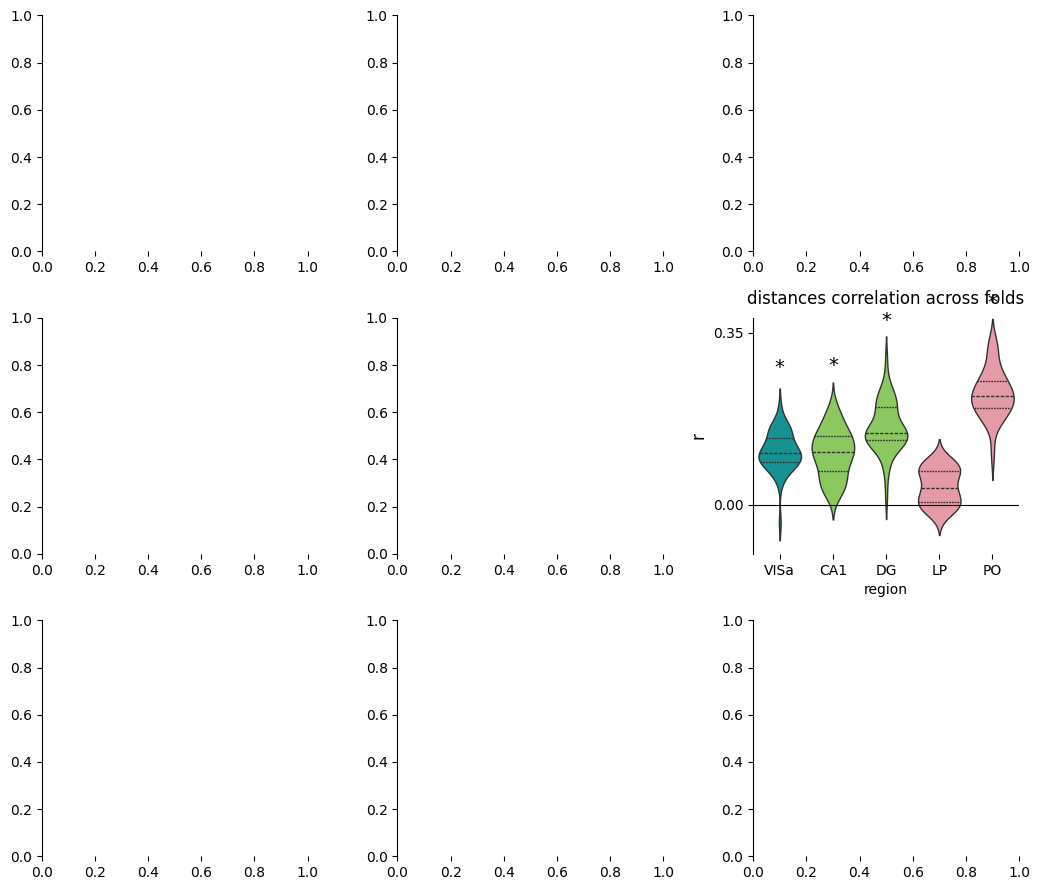

In [ ]:
# FIGURE 5 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,6*1.5))

axes = axes.flatten()

colors = [ '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F', '#FF90FF']
#colors = ['#03A6A6', '#03A6A6', '#03A6A6', '#FF90FF', '#F28D9F']

palette = dict(zip(regions, colors))

# Plot distribution of correlations for each region
axes[5].set_title("distances correlation across folds", fontsize=12, pad=10)

# Use palette only (remove explicit 'color' to let palette apply correctly)
sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)
axes[5].axhline(0, color='k', linewidth=.8)
axes[5].set_ylabel("r", fontsize=12)
axes[5].set_yticks([0, 0.35])
axes[5].set_ylim(-0.1, 0.38)

# Add significance stars where the lower 2.5% percentile of the distribution > 0
for i, region in enumerate(regions):
    vals = region_info.loc[region_info['region'] == region, 'corr'].values
    if len(vals) == 0:
        continue
    lower = np.nanpercentile(vals, 2.5)
    if lower > 0:
        # compute a y position just above the data for this region
        ylim = axes[5].get_ylim()
        data_max = np.nanmax(vals)
        margin = 0.02 * (ylim[1] - ylim[0])
        y = data_max + margin
        # expand ylim if needed to make the star visible
        if y > ylim[1] - margin:
            axes[5].set_ylim(ylim[0], y + margin)
        axes[5].text(i, y+0.05, '*', ha='center', va='bottom', fontsize=14, color='k')

plt.tight_layout()
sns.despine(bottom=True)

In [59]:
# Checking the mean and confidence intervals of the correlations for each region
all_c_corrs_np = np.array(all_regions_c_corrs)
for i, region in enumerate(regions):
    print("mean correlation for region", region)
    print(np.nanmean(all_c_corrs_np[i]))
    print("5th and 95th percentiles for region", region)
    print(np.nanpercentile(all_c_corrs_np[i], [5,95]))

mean correlation for region VISa
0.10889589875455119
5th and 95th percentiles for region VISa
[0.05587319 0.16526516]
mean correlation for region CA1
0.10509502523341333
5th and 95th percentiles for region CA1
[0.02754925 0.18317089]
mean correlation for region DG
0.15777067458345448
5th and 95th percentiles for region DG
[0.08273918 0.23708793]
mean correlation for region LP
0.037110982585362155
5th and 95th percentiles for region LP
[-0.01654368  0.08890629]
mean correlation for region PO
0.2266781310417676
5th and 95th percentiles for region PO
[0.16652398 0.32019528]


### Now, the last 3 figures are from ASD analysis

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy.cluster import hierarchy
from collections import defaultdict
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel

%load_ext autoreload
%autoreload 2
import imp
sys.path.append("./ibl_autism/scripts/")
from utils import plot_mds_pca, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, filter_distributions_outliers
from matplotlib.colors import Normalize
from metric import dsd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Load all unit kernels for each animal and region - separating across genotypes
# Plot average kernel per genotype across all regions 

genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:

        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for extreme outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)


In [10]:
# Load and organize the kernels in one array
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    print(g)
    arrs = genotype_kernels_neurons[g]
    # Keeping the most relevant conditions to reduce dimensionality (from 9*106 to 3*106)
    arrs = [a[:,3:6,:] for a in arrs] 
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    vals = [a.reshape(a.shape[0], -1).T for a in arrs if len(a) >= 100] # (n_neurons, contrast*timepoints) for each subject

    # filtering
    vals = filter_distributions_outliers(vals, percentile_upper=97.5)
    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)

# Compute distances
labels_arr = np.array(all_genotypes)

S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i], all_subjects[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)


N
F
C
S


In [11]:
# FOR THE STATISTICAL TEST OF DIFFERENCES: get the neural distances and compute:
# 1. distance matrix within control (mean for each control subject to each other control subject)
# 2. distance matrix between each control and each other genotype (so, each control and the average distance between subjects of a genotype)
# 3. now you have #ControlSubjects references and 4 variations 

def within_distance(dist_matrix, labels, genotype):
    mask_g = labels == genotype
    within = dist_matrix[np.ix_(mask_g, mask_g)]
    return within

def across_distance(dist_matrix, labels, g1, g2):
    mask_g1 = labels == g1
    mask_g2 = labels == g2
    return dist_matrix[np.ix_(mask_g1, mask_g2)]

# Get mean distances for each control (first dimension) subject
control = within_distance(dist_neural, labels_arr, 'N').mean(axis=1)
control_vs_F = across_distance(dist_neural, labels_arr, 'N', 'F').mean(axis=1)
control_vs_C = across_distance(dist_neural, labels_arr, 'N', 'C').mean(axis=1)
control_vs_S = across_distance(dist_neural, labels_arr, 'N', 'S').mean(axis=1)

# create a dataframe for plotting
df_control_distances = pd.DataFrame({
    'control_subject': np.arange(len(control)),
    'Within control': control,
    'Control vs S': control_vs_S,
    'Control vs F': control_vs_F,
    'Control vs C': control_vs_C,
})


In [12]:

def plot_dendogram(dist_neural, labs, fig=None, save=False, lab_to_color=None, title=False):
    
    S = dist_neural.shape[0]
    
    dist_neural_flat = dist_neural[np.triu_indices(S,1)] #squareform(dist_neural)

    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    if fig is None:
        fig = plt.figure(figsize=(4,5))
    # Plot all together in the same figure...
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.02)

    ax_dendro = fig.add_subplot(gs[0])
    ax_heatmap = fig.add_subplot(gs[1])

    dn = hierarchy.dendrogram(
        linkage, 
        ax=ax_dendro, 
        color_threshold=0, 
        above_threshold_color='k'
    )
    ax_dendro.axis('off')

    leaf_order = hierarchy.leaves_list(
        hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    )
    if lab_to_color is None:
        unique_labs = np.unique(labs)
        cmap = plt.get_cmap('tab10') 
        lab_to_color = {lab: cmap(i / len(unique_labs)) for i, lab in enumerate(unique_labs)}

    x_coords = np.arange(5, S * 10 + 5, 10)

    for i, original_idx in enumerate(leaf_order):
        lab = labs[original_idx]
        color = lab_to_color[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=60, zorder=10, clip_on=False)

    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    
    ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto', 
                      vmin=np.min(ordered_dist), vmax=np.max(ordered_dist))

    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])

    if title:
        plt.title('Distance matrix with dendrogram ordering', fontsize=12, y=1.2)
    
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)

    if save:
        plt.savefig(f"distance_dendrogram.png", dpi=300, bbox_inches='tight')
    
    return fig, ax_dendro, ax_heatmap


/tmp/ipykernel_3248112/787280581.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


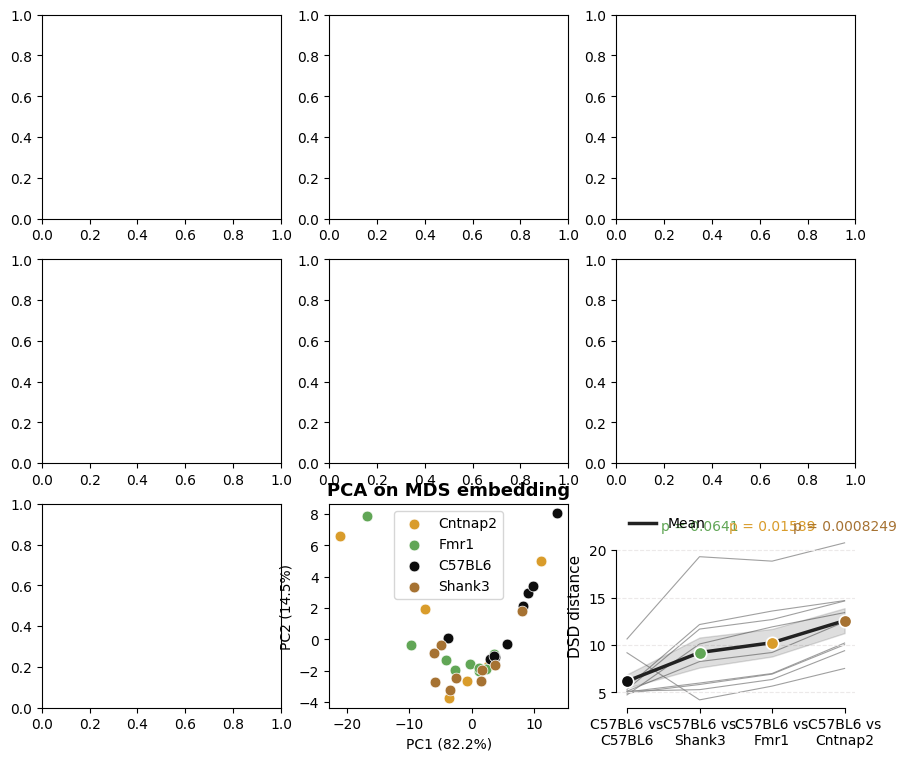

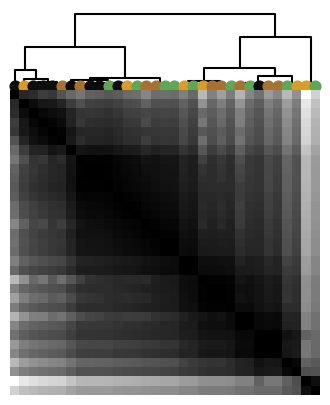

In [14]:
## Figure 6-8

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,6*1.5))
axes = axes.flatten()

## FIG 6 - HIERARCHICAL CLUSTERING AND ORDERING 
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
fig_dendo, ax_dendro, ax_heatmap = plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors, title=False, save=False)

# FIG 7 - PLOT PCA
ax_pca, ax_mds = plot_mds_pca(dist_neural, labels_arr, ax=axes[7])

# FIG 8 - PLOT TTESTS

cols = ['Within control', 'Control vs S', 'Control vs F', 'Control vs C']
x_labels = ['C57BL6 vs\nC57BL6', 'C57BL6 vs\nShank3', 'C57BL6 vs\nFmr1', 'C57BL6 vs\nCntnap2']

for _, row in df_control_distances[cols].iterrows():
    axes[8].plot(range(len(cols)), row.values, color='#888888', alpha=0.8, linewidth=0.8, zorder=1)

means = df_control_distances[cols].mean(axis=0)
sem = df_control_distances[cols].sem(axis=0)

axes[8].fill_between(range(len(cols)), means - sem, means + sem, 
                color='#222222', alpha=0.15, zorder=2)

mean_colors = ['#0D0D0D', '#61A656', '#D99C2B', '#A67232']
axes[8].plot(range(len(cols)), means.values, color='#222222', linewidth=2.5, zorder=3, label='Mean')

for xi, col in enumerate(cols):
    axes[8].scatter(xi, means[col], color=mean_colors[xi], s=80, zorder=4, edgecolor='white', linewidth=1.2)

results = {}
a = df_control_distances['Within control'].values
y_max_val = df_control_distances[cols].max().max() # Reference for placing asterisks

for xi, col in enumerate(['Control vs S', 'Control vs F', 'Control vs C'], start=1):
    b = df_control_distances[col].values
    mask = (~np.isnan(a)) & (~np.isnan(b))
    
    if mask.sum() >= 2:
        t_stat, p_val = ttest_rel(a[mask], b[mask])
        results[col] = {'n': int(mask.sum()), 't': float(t_stat), 'p': float(p_val)}
        
        # Determine asterisks for significance
        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = ''

        axes[8].text(xi, y_max_val + (0.05 * y_max_val), f'p = {p_val:.4g}', ha='center', va='bottom',
                            fontsize=10, color=mean_colors[xi])
            

axes[8].set_xticks(range(len(cols)))
axes[8].set_xticklabels(x_labels, fontsize=10)
axes[8].set_ylabel('DSD distance', fontsize=11, fontweight='medium')

ymin, ymax = axes[8].get_ylim()
axes[8].set_ylim(ymin, ymax + (ymax - ymin) * 0.18)

sns.despine(ax=axes[8], trim=True)
axes[8].grid(axis='y', color="#ECE9E9", linewidth=0.8, linestyle='--')
axes[8].grid(axis='x', visible=False) 
axes[8].legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:

## Figure 6-8

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,6*1.5))

## FIG 6 - PCA of distances across subjects (axes[6])
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
axes = axes.flatten()
# PCA in axes[6]
ax_pca, ax_mds = plot_mds_pca(dist_neural, labels_arr, ax=axes[6])

## FIG 7 - ORDERED DISTANCE MATRIX + DENDROGRAM (axes[7])
from scipy.cluster import hierarchy
import matplotlib.colors as mcolors

S = dist_neural.shape[0]
condensed = dist_neural[np.triu_indices(S,1)]
linkage = hierarchy.ward(condensed)
linkage = hierarchy.optimal_leaf_ordering(linkage, condensed)
leaf_order = hierarchy.leaves_list(linkage)

# Prepare ordered distance
ordered_dist = dist_neural[leaf_order, :][:, leaf_order]

# Compute axes positions and create dendrogram + heatmap inside axes[7]
pos = axes[7].get_position()
left, bottom, width, height = pos.x0, pos.y0, pos.width, pos.height
# Remove original axes[7] and create new sub-axes in its place
axes[7].clear()
heatmap_ax = fig.add_axes([left, bottom, width, height*0.75])
dendro_ax = fig.add_axes([left, bottom + height*0.75, width, height*0.25])

# Draw dendrogram
dn = hierarchy.dendrogram(linkage, ax=dendro_ax, no_labels=True, color_threshold=0)
dendro_ax.axis('off')

# Draw heatmap with ordered distances
heatmap_ax.imshow(ordered_dist, cmap='gray', aspect='auto', vmin=np.nanmin(ordered_dist), vmax=np.nanmax(ordered_dist))
heatmap_ax.set_xticks([])
heatmap_ax.set_yticks([])

# Add a color strip showing genotype labels on left
lab_to_color = colors
ordered_labels = labels_arr[leaf_order]
color_list = mcolors.to_rgba_array([lab_to_color[lab] for lab in ordered_labels])
cax = fig.add_axes([left - 0.02, bottom, 0.015, height*0.75])
cax.imshow(color_list.reshape(-1,1,4), aspect='auto')
cax.set_xticks([])
cax.set_yticks([])

## FIG 8 - PARALLEL T-TEST PLOT (axes[8])
cols = ['Within control', 'Control vs S', 'Control vs F', 'Control vs C']
x_labels = ['C57BL6 vs\nC57BL6', 'C57BL6 vs\nShank3', 'C57BL6 vs\nFmr1', 'C57BL6 vs\nCntnap2']

for _, row in df_control_distances[cols].iterrows():
    axes[8].plot(range(len(cols)), row.values, color='#888888', alpha=0.8, linewidth=0.8, zorder=1)

means = df_control_distances[cols].mean(axis=0)
sem = df_control_distances[cols].sem(axis=0)

axes[8].fill_between(range(len(cols)), means - sem, means + sem,
                color='#222222', alpha=0.15, zorder=2)

mean_colors = ['#0D0D0D', '#61A656', '#D99C2B', '#A67232']
axes[8].plot(range(len(cols)), means.values, color='#222222', linewidth=2.5, zorder=3, label='Mean')

for xi, col in enumerate(cols):
    axes[8].scatter(xi, means[col], color=mean_colors[xi], s=80, zorder=4, edgecolor='white', linewidth=1.2)

results = {}
a = df_control_distances['Within control'].values
y_max_val = df_control_distances[cols].max().max()

for xi, col in enumerate(['Control vs S', 'Control vs F', 'Control vs C'], start=1):
    b = df_control_distances[col].values
    mask = (~np.isnan(a)) & (~np.isnan(b))
    if mask.sum() >= 2:
        t_stat, p_val = ttest_rel(a[mask], b[mask])
        results[col] = {'n': int(mask.sum()), 't': float(t_stat), 'p': float(p_val)}
        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = ''
        axes[8].text(xi, y_max_val + (0.05 * y_max_val), f'p = {p_val:.4g}', ha='center', va='bottom', fontsize=10, color=mean_colors[xi])

axes[8].set_xticks(range(len(cols)))
axes[8].set_xticklabels(x_labels, fontsize=10)
axes[8].set_ylabel('DSD distance', fontsize=11, fontweight='medium')

ymin, ymax = axes[8].get_ylim()
axes[8].set_ylim(ymin, ymax + (ymax - ymin) * 0.18)

sns.despine(ax=axes[8], trim=True)
axes[8].grid(axis='y', color="#ECE9E9", linewidth=0.8, linestyle='--')
axes[8].grid(axis='x', visible=False)
axes[8].legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

import pickle